In [1]:
import numpy as np

import torch
import torch.optim as optim
import torch.nn as nn
import torch.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc
from stepbystep.v0 import StepByStep

# Data Generation

In [2]:
X, y = make_moons(n_samples=100, noise=0.3, random_state=0)

In [3]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=.2, random_state=13)

In [4]:
sc = StandardScaler()
sc.fit(X_train)

X_train = sc.transform(X_train)
X_val = sc.transform(X_val)

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def figure1(X_train, y_train, X_val, y_val, cm_bright=None):
    if cm_bright is None:
        cm_bright = ListedColormap(['#FF0000', '#0000FF'])

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright)
    ax[0].set_xlabel(r'$X_1$')
    ax[0].set_ylabel(r'$X_2$')
    ax[0].set_xlim([-2.3, 2.3])
    ax[0].set_ylim([-2.3, 2.3])
    ax[0].set_title('Generated Data - Train')

    ax[1].scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap=cm_bright)
    ax[1].set_xlabel(r'$X_1$')
    ax[1].set_ylabel(r'$X_2$')
    ax[1].set_xlim([-2.3, 2.3])
    ax[1].set_ylim([-2.3, 2.3])
    ax[1].set_title('Generated Data - Validation')
    fig.tight_layout()
    plt.show()

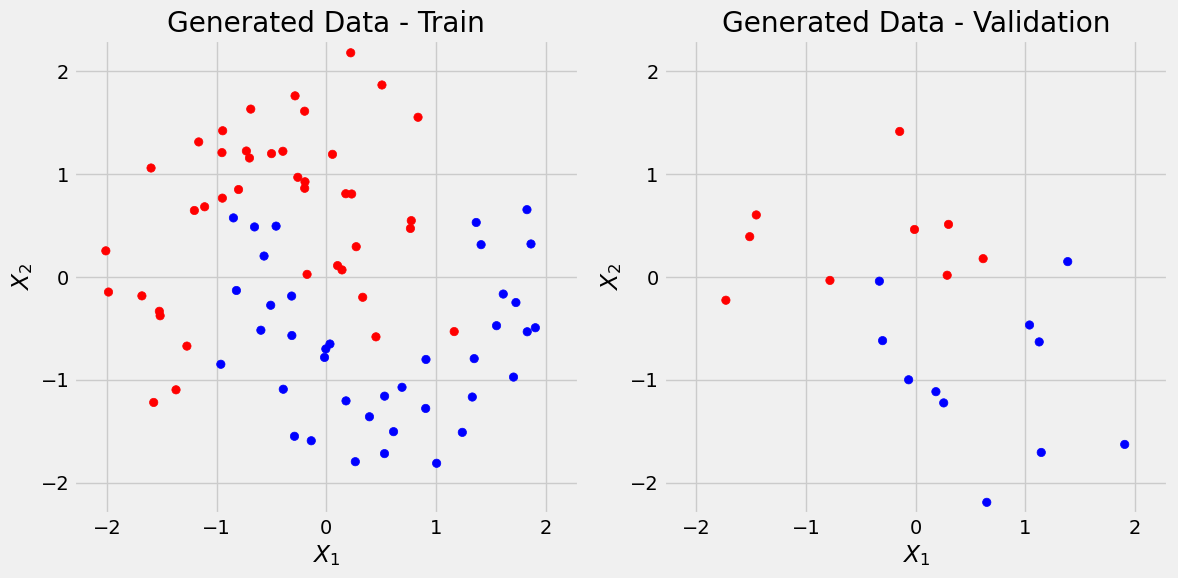

In [6]:
figure1(X_train, y_train, X_val, y_val)

# Data Preparation

In [7]:
torch.manual_seed(13)

# build tensors from Numpy arrays
x_train_tensor = torch.as_tensor(X_train).float()
y_train_tensor = torch.as_tensor(y_train.reshape(-1, 1)).float()

x_val_tensor = torch.as_tensor(X_val).float()
y_val_tensor = torch.as_tensor(y_val.reshape(-1, 1)).float()

# builds dataset containing all data points
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)

# builds a loader of each set
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=16,
    shuffle=True
)
val_loader = DataLoader(dataset=val_dataset, batch_size=16)

In [8]:
def odd_ratio(prob):
    return prob / (1 - prob)

p = .75
q = 1 - p
odd_ratio(p), odd_ratio(q)

(3.0, 0.3333333333333333)

In [21]:
def figure2(prob1):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    prob = np.linspace(.01, .99, 99)
    for i in [0, 1]:
        ax[i].plot(prob, odd_ratio(prob), linewidth=2)
        ax[i].set_xlabel('Probability')
        if i:
            ax[i].set_yscale('log')
            ax[i].set_ylabel('Odds Ratio (log scale)')
            ax[i].set_title('Odds Ratio (log scale)')
        else:
            ax[i].set_ylabel('Odds Ratio')
            ax[i].set_title('Odds Ratio')
        ax[i].scatter([prob1, .5, (1 - prob1)], [odd_ratio(prob1), odd_ratio(.5), odd_ratio(1 - prob1)], c='r')
    fig.tight_layout()
    return fig

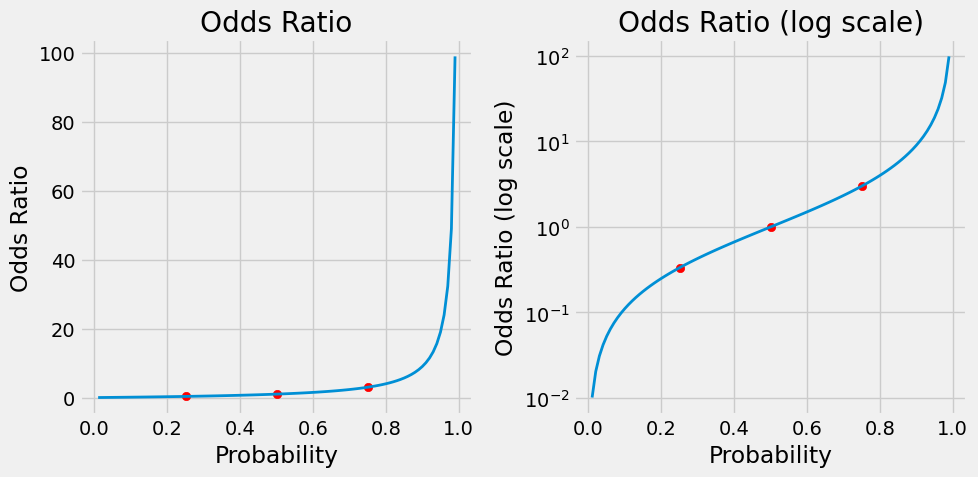

In [22]:
fig = figure2(p)

In [23]:
def log_odds_ratio(prob):
    return np.log(odd_ratio(prob))
p = .75
q = 1 - p
log_odds_ratio(p), log_odds_ratio(q)

(np.float64(1.0986122886681098), np.float64(-1.0986122886681098))

In [29]:
def figure3(prob1):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    prob = np.linspace(.01, .99, 99)

    ax[0].plot(prob, log_odds_ratio(prob), linewidth=2)
    ax[0].set_xlabel('Probability')
    ax[0].set_ylabel('Log Odds Ratio')
    ax[0].set_title('Log Odds Ratio')
    ax[0].scatter([prob1, .5, (1-prob1)], [log_odds_ratio(prob1), log_odds_ratio(.5), log_odds_ratio(1-prob1)], c='r')
    
    ax[1].plot(log_odds_ratio(prob), prob, linewidth=2)
    ax[1].set_xlabel('Probability')
    ax[1].set_ylabel('Log Odds Ratio')
    ax[1].set_title('Probability')
    ax[1].scatter([log_odds_ratio(prob1), log_odds_ratio(.5), log_odds_ratio(1-prob1)], [prob1, .5, (1-prob1)], c='r')

    return fig

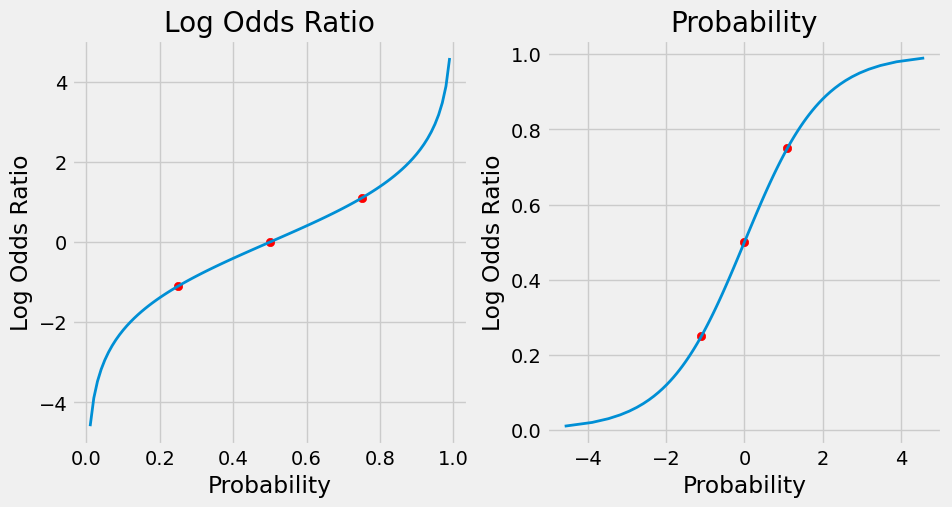

In [30]:
fig = figure3(p)

In [31]:
# sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

p = .75
q = 1 - p
sigmoid(log_odds_ratio(p)), sigmoid(log_odds_ratio(q))

(np.float64(0.75), np.float64(0.25))

In [32]:
torch.sigmoid(torch.tensor(1.0986)), torch.sigmoid(torch.tensor(-1.0986))

(tensor(0.7500), tensor(0.2500))

In [37]:
def figure4(prob1):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    prob = np.linspace(.01, .99, 99)

    ax.plot(log_odds_ratio(prob), prob, linewidth=2, c='r')
    ax.set_ylabel('Probability')
    ax.set_xlabel('Log Odds Ratio')
    ax.set_title('Sigmoid')
    ax.scatter([log_odds_ratio(prob1), log_odds_ratio(.5), log_odds_ratio(1-prob1)], [prob1, .5, (1-prob1)], c='r')
    fig.tight_layout()
    return fig


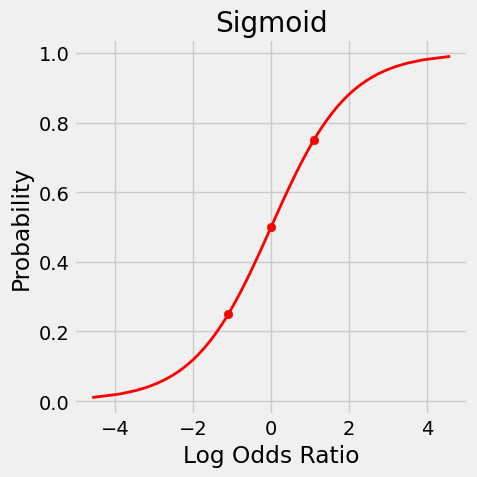

In [38]:
fig = figure4(p)

In [40]:
torch.manual_seed(42)
model1 = nn.Sequential()
model1.add_module('linear', nn.Linear(2, 1))
model1.add_module('sigmoid', nn.Sigmoid())
print(model1.state_dict())

OrderedDict([('linear.weight', tensor([[0.5406, 0.5869]])), ('linear.bias', tensor([-0.1657]))])
